### Nelli Poghosyan
### Section B
### DS120: Programming for Data Science: Project


The link to the selected dataset: https://www.kaggle.com/datasets/armanansari/imdb-anime-data

#### Comprehensive documentation of all steps undertaken

In this project I analyzed a dataset of anime.
The dataset originally contains 1000 anime(rows) and after cleaning 742 remained, with columns of their ratings, votes, genres, duration and release years.

My goal was to explore what makes anime popular and highly rated, does the era matter? does popularity mean better ratings? which genres dominate?

To answer these questions I built three classes:
DataLoader — loads and cleans the raw data
DataAnalyzer — analyzes the data and finds patterns
Visualizer — creates plots to visualize the findings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Part1: DataLoader

In [2]:
class DataLoader:
    def __init__(self, file):
        self.file = file
        self.df = None
# I stored the path to the CSV file so load() can access it and created an empty dataframe variable

    def load(self):
        self.df = pd.read_csv(self.file, index_col=0)
# I loaded the CSV into a DataFrame, dropping the useless index column    

        self.df.columns = ["title", "release_year", "genre", "duration", "rating", "description", "votes"]
        # I renamed the columns to make them cleaner and easier to use

        self.df["start_year"] = pd.to_numeric(
            self.df["release_year"].str[:4].str.strip(),
            errors="coerce").astype("Int64")
        # I extracted only the starting year from release_year

        self.df["release_year"] = self.df["release_year"].str.replace("OA", "present")
        # I replaced "OA" into present, so that it will be more understandable

        self.df["status"] = np.where(self.df["release_year"].str[-7:] == "present", "Ongoing", "Finished")
        # I used np.where to create a status column based on whether the anime is still ongoing or finished

        self.df["votes"] = pd.to_numeric(self.df["votes"].str.replace(",", ""), errors="coerce").astype("Int64")
        # I removed commas from votes and converted them to integers for numerical analysis
       
        self.df = self.df.drop_duplicates() 
         # I removed duplicate rows if they exist
         
        self.df["primary_genre"] = self.df["genre"].str.split(",").str[0]
        self.df["genre"] = (self.df["genre"].fillna("").str.split(","))
        # First I created a new column containing only the primary genre, then converted genres into lists for easier analysis later

        self.df = self.df.dropna(subset=["rating", "votes"], how="any")
        # I removed rows where either rating or votes are missing

        median_duration = self.df["duration"].median()
        self.df["duration"] = self.df["duration"].fillna(median_duration).astype("Int64")
        # I calculated the median duration to fill the missing duration values with it, so it will be easier for later analysis

        self.df = self.df.reset_index(drop=True)
        # I reset the index after cleaning
        return self.df
    


In [3]:
loader = DataLoader('imdb_anime_data copy.csv')
df = loader.load()
print(f"Here is your cleaned data ({df.shape[0]} rows, {df.shape[1]} columns):")
df.head(10)

Here is your cleaned data (742 rows, 10 columns):


,title,release_year,genre,duration,rating,description,votes,start_year,status,primary_genre
0,One Piece,1999–present,"[Animation, Action, Adventure]",24,8.9,Follows the adventures of Monkey D. Luffy and ...,195880,1999,Ongoing,Animation
1,Jujutsu Kaisen,2020–present,"[Animation, Action, Adventure]",24,8.5,A boy swallows a cursed talisman - the finger ...,85982,2020,Ongoing,Animation
2,Attack on Titan,2013–2023,"[Animation, Action, Adventure]",24,9.0,After his hometown is destroyed and his mother...,442112,2013,Finished,Animation
3,Bleach: Thousand-Year Blood War,2022–present,"[Animation, Action, Adventure]",24,9.0,The peace is suddenly broken when warning sire...,30485,2022,Ongoing,Animation
4,Demon Slayer: Kimetsu no Yaiba,2019–present,"[Animation, Action, Adventure]",24,8.6,A family is attacked by demons and only two me...,133448,2019,Ongoing,Animation
5,Mushoku Tensei: Jobless Reincarnation,2021–present,"[Animation, Action, Adventure]",24,8.4,A 34-year-old Japanese NEET is run over by a s...,16743,2021,Ongoing,Animation
6,Naruto: Shippuden,2007–2017,"[Animation, Action, Adventure]",24,8.7,"Naruto Uzumaki, is a loud, hyperactive, adoles...",147254,2007,Finished,Animation
7,Cyberpunk: Edgerunners,2022,"[Animation, Action, Adventure]",24,8.3,A Street Kid trying to survive in a technology...,65529,2022,Finished,Animation
8,Bleach,2004–2023,"[Animation, Action, Adventure]",24,8.2,"High school student Ichigo Kurosaki, who has t...",65287,2004,Finished,Animation
9,Naruto,2002–2007,"[Animation, Action, Adventure]",24,8.4,"Naruto Uzumaki, a mischievous adolescent ninja...",118711,2002,Finished,Animation


### Part2: DataAnalyzer

In [4]:
class DataAnalyzer:
    def __init__(self, df):
        self.df = df.copy()
    # I stored the cleaned DataFrame passed in from DataLoader

    def descriptive_stats(self):
        stats = self.df[["rating", "votes", "duration", "start_year"]].describe()
        print("Descriptive Statistics:")
        print(stats)
    # I computed general descriptive statistics to understand the overall spread of the data

        print("Additional statistics done by NumPy:")
        print(f"Mean rating: {np.mean(self.df["rating"].dropna())}")
        print(f"Median rating:  {np.median(self.df['rating'].dropna())}")
        print(f"Std rating:     {np.std(self.df['rating'].dropna())}")
        print(f"Max votes:      {np.max(self.df['votes'].dropna())}")
        print(f"Min votes:      {np.min(self.df['votes'].dropna())}")
        return stats
    # Additionally used NumPy to manually compute additional statistics not covered by describe()
    
    def add_era_column(self):
        year = self.df["start_year"].fillna(0).astype("int64").to_numpy()
        self.df["era"] = np.where(year <= 1999, "Retro",np.where(year <= 2012, "Modern", "Recent"))
        print("Era column added")
        display(self.df[["title", "era"]].head(10))
        return self
    # I created new column named "era" to classify each anime into a historical era based on its start year using np.where()
    
    def add_popularity_col(self):
        votes = self.df["votes"]
        mean = votes.mean()
        self.df["popularity"] = np.where(votes <= mean * 0.5, "Low", np.where(votes <= mean * 2, "Medium", "High"))
        print("Popularity column:")
        display(self.df[["title", "popularity"]].head(10))
        return self
    # I used np.where with mean to divide votes into three popularity parts and added popularity column.

    def genre_statistics(self):
        st = (self.df.groupby("primary_genre").agg(avg_rating=("rating", "mean"), total_votes=("votes", "sum"), count=("title", "count"))).round(2).sort_values("avg_rating", ascending=False)
        print("Genre Statistics:")
        display(st.head(10))
        return st
        # I grouped by primary genre and computed mean rating, total votes and count. I sorted them by decreasing order by avg_rating.
        # This shows which genres are most loved and most watched

    def era_statistics(self):
        st = (self.df.dropna(subset=["era"]).groupby("era").agg(avg_rating=("rating", "mean"),
                avg_votes=("votes", "mean"),
                count=("title", "count")).round(2))
        print("Era Statistics:")
        display(st)
        return st
    # I group by era to see how anime ratings and popularity changed across generations
                 
    def top_era(self):
        index = (self.df.dropna(subset=["era"]).groupby("era")["rating"].idxmax())
        top = self.df.loc[index, ["title", "era", "rating", "votes"]].reset_index(drop=True)
        print("Top Rated Anime per Era:")
        display(top)
        return top
    # I found the highest rated anime in each era using idxmax which returns the index of the row with the highest rating per group.
    # Then I used loc to retrieve the top rated anime per era by their index.

    def ongoing_vs_finished(self):
        ong_vs_fin = (self.df.groupby("status").agg(avg_rating=("rating", "mean"), avg_votes=("votes", "mean"), count=("title", "count")).round(2))
        print("Ongoing vs Finished: ")
        display(ong_vs_fin)
        return ong_vs_fin
    # I grouped by status to compare average rating and votes between ongoing and finished anime

    def top10_by_rating(self):
        top10 = (self.df[["title", "rating", "votes", "primary_genre", "era"]].sort_values("rating", ascending=False).head(10).reset_index(drop=True))
        print("Top 10 anime by rating:")
        display(top10)
        return top10
    # I filtered and sort to find the top 10 highest rated anime in the dataset

    def get_data(self):
        return self.df
    # I returned the enriched dataframe with all the new derived columns added

In [5]:
analyzer = DataAnalyzer(df)
analyzer.descriptive_stats()
analyzer.add_era_column()
analyzer.add_popularity_col()
genre_stats = analyzer.genre_statistics()
era_stats = analyzer.era_statistics()
top_per_era = analyzer.top_era()
airing_stats = analyzer.ongoing_vs_finished()
top10 = analyzer.top10_by_rating()
df_new  = analyzer.get_data()

Descriptive Statistics:
           rating         votes   duration   start_year
count  742.000000         742.0      742.0        735.0
mean     7.090566  12902.028302  44.902965  2009.808163
std      1.038057  59739.208452   44.32966    11.182286
min      1.700000           5.0        2.0       1963.0
25%      6.600000         45.25       24.0       2004.0
50%      7.200000         679.5       25.0       2013.0
75%      7.800000        5485.0       56.5       2018.0
max      9.200000     1160486.0      650.0       2023.0
Additional statistics done by NumPy:
Mean rating: 7.090566037735849
Median rating:  7.2
Std rating:     1.0373574414214422
Max votes:      1160486
Min votes:      5
Era column added


,title,era
0,One Piece,Retro
1,Jujutsu Kaisen,Recent
2,Attack on Titan,Recent
3,Bleach: Thousand-Year Blood War,Recent
4,Demon Slayer: Kimetsu no Yaiba,Recent
5,Mushoku Tensei: Jobless Reincarnation,Recent
6,Naruto: Shippuden,Modern
7,Cyberpunk: Edgerunners,Recent
8,Bleach,Modern
9,Naruto,Modern


Popularity column:


,title,popularity
0,One Piece,High
1,Jujutsu Kaisen,High
2,Attack on Titan,High
3,Bleach: Thousand-Year Blood War,High
4,Demon Slayer: Kimetsu no Yaiba,High
5,Mushoku Tensei: Jobless Reincarnation,Medium
6,Naruto: Shippuden,High
7,Cyberpunk: Edgerunners,High
8,Bleach,High
9,Naruto,High


Genre Statistics:


...

,title,era,rating,votes
0,Fullmetal Alchemist: Brotherhood,Modern,9.1,186592
1,The Demon Sword Master of Excalibur Academy,Recent,9.2,29
2,Legend of the Galactic Heroes,Retro,9.0,4335


Ongoing vs Finished: 


,avg_rating,avg_votes,count
status,,,
Finished,7.14,13460.63,641
Ongoing,6.80,9356.84,101


Top 10 anime by rating:


,title,rating,votes,primary_genre,era
0,The Demon Sword Master of Excalibur Academy,9.2,29,Animation,Recent
1,Fullmetal Alchemist: Brotherhood,9.1,186592,Animation,Modern
2,Legend of the Galactic Heroes,9.0,4335,Animation,Retro
3,Attack on Titan,9.0,442112,Animation,Recent
4,Paranormasight: The Seven Mysteries of Honjo,9.0,10,Adventure,Recent
5,Hunter x Hunter,9.0,121124,Animation,Modern
6,Bleach: Thousand-Year Blood War,9.0,30485,Animation,Recent
7,Gal Guardians: Demon Purge,8.9,9,Action,Recent
8,Silver Fang,8.9,3099,Animation,Retro
9,Cowboy Bebop,8.9,131399,Animation,Retro


### Part3: Visualizer

In [6]:
class Visualizer:
    def __init__(self, df):
        self.df = df.copy()
    # I stored the enriched dataframe passed in from DataAnalyzer

    def rating(self):
        plt.figure(figsize=(10, 6))
        plt.hist(self.df["rating"].dropna(), bins=20, color="mediumseagreen", edgecolor="slateblue")
        plt.title("Rating Distribution")
        plt.xlabel("Rating")
        plt.ylabel("Count")
        plt.tight_layout()
        print("Histogram")
        plt.show()
    # I plotted a histogram to show the distribution of anime ratings

    def top_genres(self):
        top = (self.df.groupby("primary_genre")["rating"].mean().round(2).sort_values(ascending=False).head(10))
        plt.bar(top.index, top.values, color="plum", edgecolor="thistle")
        plt.title("Top 10 genres by average rating")
        plt.xlabel("genre")
        plt.ylabel("average rating")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        print("Bar Chart")
        plt.show()
    # I plotted a bar chart to show the top 10 genres by average rating

    def v_vs_r(self):
        plt.scatter(self.df["votes"], self.df["rating"], alpha=0.5, color="cadetblue")
        plt.title("Votes vs Rating")
        plt.xlabel("votes")
        plt.ylabel("rating")
        plt.tight_layout()
        print("Scatter Plot")
        plt.show()
    # I plotted a scatter plot to show the relationship between votes and rating

    def rating_by_era(self):
        sns.boxplot(data=self.df.dropna(subset=["era"]), x="era", y="rating", hue="era", palette="Set3", legend=False)
        plt.title("Rating distribution by era")
        plt.xlabel("era")
        plt.ylabel("rating")
        plt.tight_layout()
        print("Box Plot")
        plt.show()
    # I plotted a box plot to show the spread of ratings across different eras

    def avg_rating_by_year(self):
        year = (self.df.groupby("start_year")["rating"].mean().round(2))
        plt.figure(figsize=(12, 6))
        plt.plot(year.index, year.values, color="olive", linewidth=2)
        plt.title("Average rating by year")
        plt.xlabel("year")
        plt.ylabel("average rating")
        plt.tight_layout()
        print("Line Plot")
        plt.show()
    # I plotted a line plot to show how average rating changed over the years

    def avg_by_pop(self):
        pop = self.df.groupby("popularity")["rating"].mean().round(2)
        plt.bar(pop.index, pop.values, color="darksalmon", edgecolor="mistyrose")
        plt.title("Average rating by popularity")
        plt.xlabel("popularity")
        plt.ylabel("average rating")
        plt.tight_layout()
        print("Bar Chart")
        plt.show()
    # I plotted a bar chart to show average rating for each popularity level

    def popularity(self):
        count = self.df["popularity"].value_counts()
        colors = ["lightskyblue", "lightgreen", "lavender"]
        plt.pie(count.values, labels=count.index, colors=colors, autopct="%1.1f%%", startangle=90)
        plt.axis("equal")
        plt.title("Anime distribution by popularity level")
        print("Pie Chart")
        plt.show()
    # I plotted a pie chart to show what percentage of anime fall into each popularity level

    def status(self):
        count = self.df["status"].value_counts()
        colors=["darkorange", "moccasin"]
        explode=(0.1, 0)
        fig, ax = plt.subplots()
        ax.pie(count.values, explode=explode, labels=count.index, colors=colors, autopct="%1.1f%%", shadow=True, startangle=90)
        centre = plt.Circle((0, 0), 0.70, fc="white")
        fig = plt.gcf()
        fig.gca().add_artist(centre)
        plt.axis("equal")
        plt.title("Ongoing vs Finished anime")
        print("Doughnut Chart")
        plt.show()
    # I plotted a doughnut chart to show the split between ongoing and finished anime

    def rating_by_pop(self):
        l = self.df[self.df["popularity"] == "Low"]["rating"].dropna().values
        m = self.df[self.df["popularity"] == "Medium"]["rating"].dropna().values
        h = self.df[self.df["popularity"] == "High"]["rating"].dropna().values
        plt.violinplot([l, m, h])
        plt.title("Rating distribution by popularity level")
        plt.xlabel("popularity")
        plt.ylabel("rating")
        plt.xticks([1, 2, 3], ["Low", "Medium", "High"])
        print("Violin Plot")
        plt.show()
    # I plotted a violin plot to show the full shape of rating distribution for each popularity level
            

Histogram


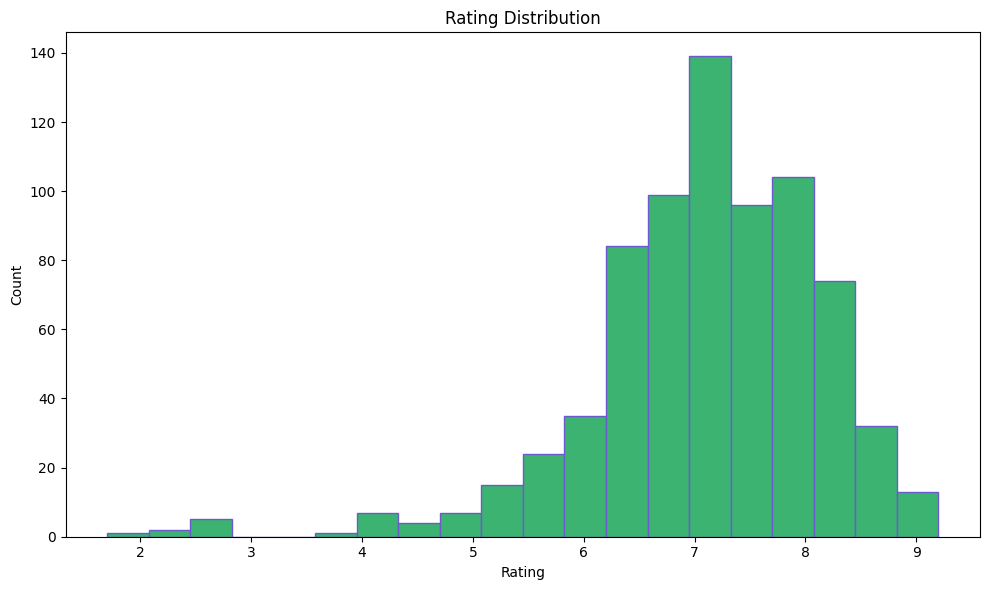

Bar Chart


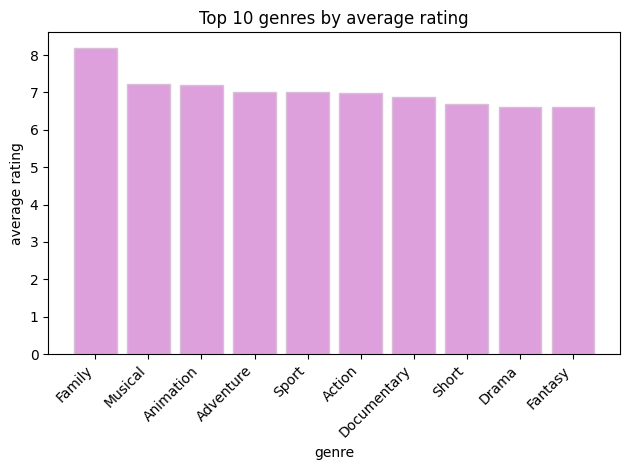

Scatter Plot


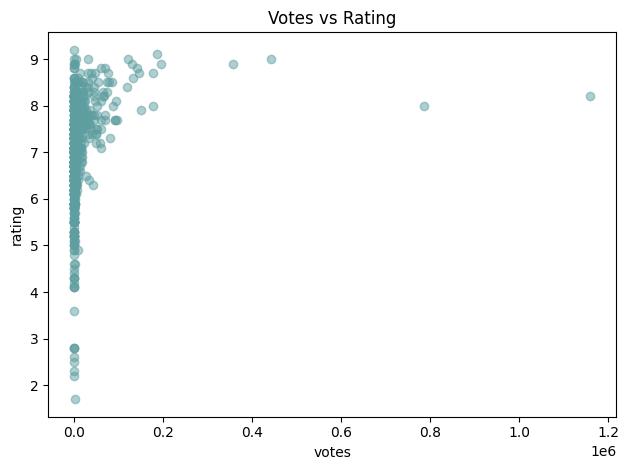

Box Plot


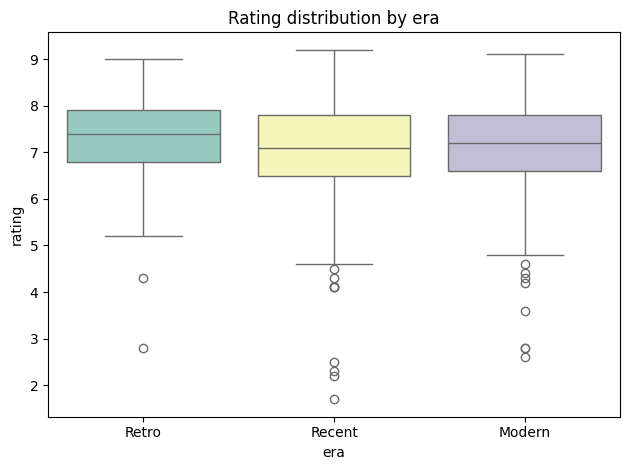

Line Plot


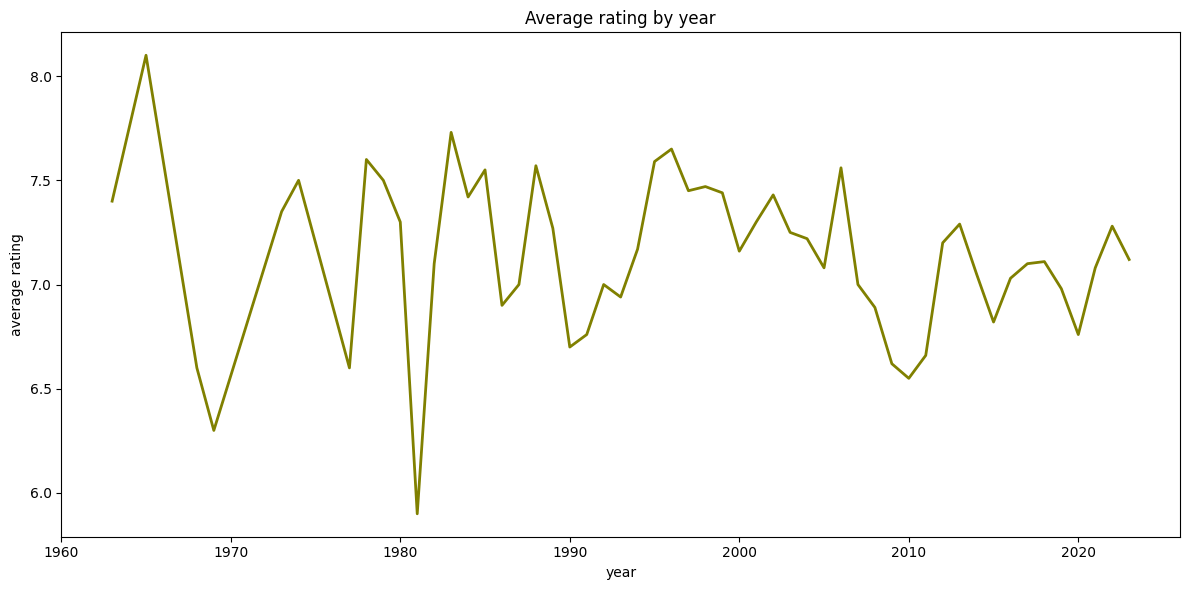

Bar Chart


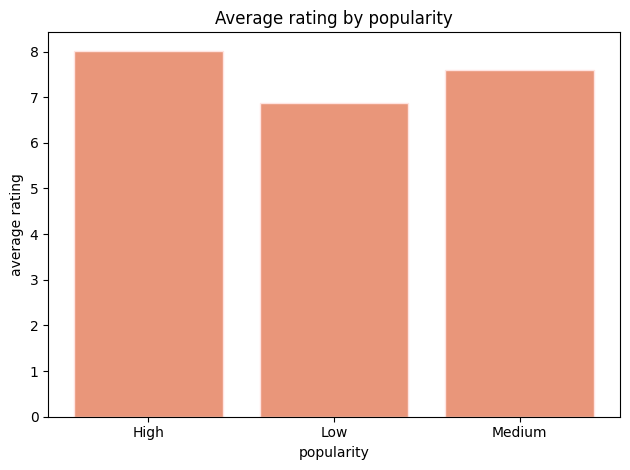

Pie Chart


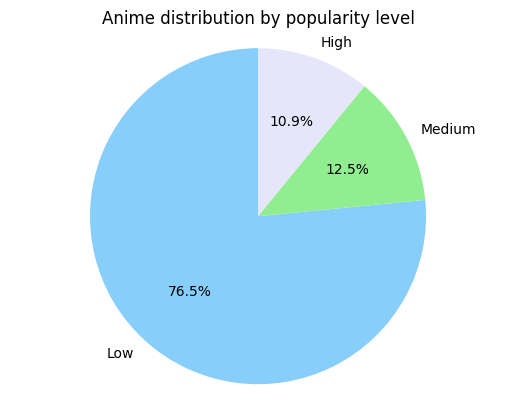

Doughnut Chart


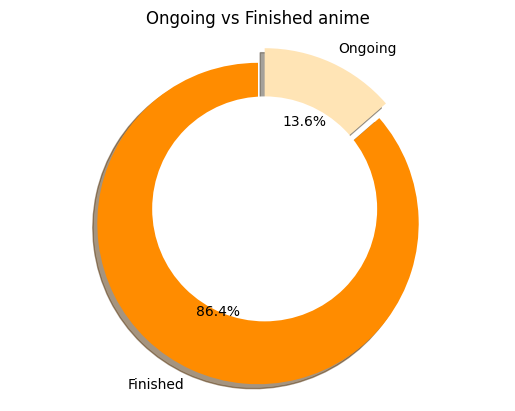

Violin Plot


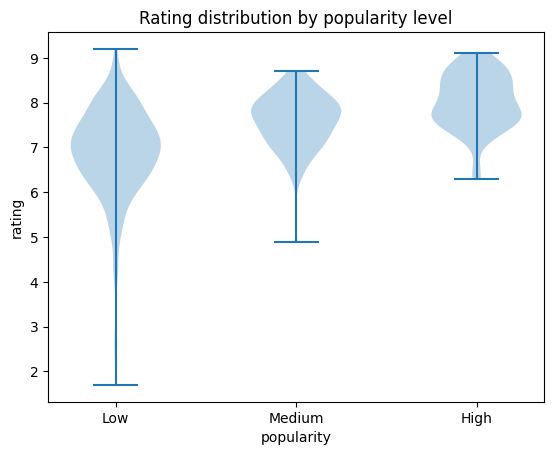

In [7]:
viz = Visualizer(df_new)
viz.rating()
viz.top_genres()
viz.v_vs_r()
viz.rating_by_era()
viz.avg_rating_by_year()
viz.avg_by_pop()
viz.popularity()
viz.status()
viz.rating_by_pop()

#### Conclusions

Ratings: Most anime are rated between 6.5 and 8.0. Very few go below 5 or above 9, meaning most anime are decent quality.

Era: Retro anime (before 2000) have the highest median ratings. This is likely because only the truly great classics are remembered and rated today.

Genres: Not all popular genres are the highest rated, some niche genres actually score higher than mainstream ones like action.

Votes vs Rating: Higher voted anime tend to be rated better, but there are hidden gems with very few votes and very high ratings.

Ongoing vs Finished: Finished anime tend to have more votes since they have had more time to accumulate attention.

Popularity: Being popular does not guarantee a high rating, Medium popularity anime sometimes outscore High popularity ones.